In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from datetime import timedelta
import sys
import itertools
import cartopy.crs as ccrs
import cartopy.feature as cfeature
land_feature=cfeature.NaturalEarthFeature(category='physical',name='land',scale='50m',facecolor=[0.4,0.6,0.7])
pr1=ccrs.PlateCarree()
from glob import glob
sys.path.insert(0, "/home/kbalem/Bureau/VirtualFleet/") # This is when you load VirtualFleet functions
from virtualargofleet import Velocity, FloatConfiguration, VirtualFleet

/home/kbalem/miniforge3/envs/x26K/lib/python3.11/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [2]:
import parcels
parcels.__version__ 

'3.1.4'

In [54]:
files = glob('data/cmems_glorysInt_octnov_2021.nc')
files.sort()
print(files[0],'\n to \n',files[-1])
ds = xr.open_dataset(files[0])
ds

data/cmems_glorysInt_octnov_2021.nc 
 to 
 data/cmems_glorysInt_octnov_2021.nc


<xarray.Dataset> Size: 263MB
Dimensions:    (time: 47, depth: 50, latitude: 97, longitude: 144)
Coordinates:
  * time       (time) datetime64[ns] 376B 2021-10-15 2021-10-16 ... 2021-11-30
  * depth      (depth) float32 200B 0.494 1.541 2.646 ... 5.275e+03 5.728e+03
  * latitude   (latitude) float32 388B 15.0 15.08 15.17 ... 22.83 22.92 23.0
  * longitude  (longitude) float32 576B -70.0 -69.92 -69.83 ... -58.17 -58.08
Data variables:
    uo         (time, depth, latitude, longitude) float32 131MB ...
    vo         (time, depth, latitude, longitude) float32 131MB ...
Attributes:
    Conventions:       CF-1.11
    title:             cmems_mod_glo_phy_myint_0.083deg_P1D-m_202311
    subset:source:     ARCO data downloaded from the Marine Data Store using ...
    subset:productId:  GLOBAL_MULTIYEAR_PHY_001_030
    subset:datasetId:  cmems_mod_glo_phy_myint_0.083deg_P1D-m_202311
    subset:date:       2025-07-07T13:09:11.305Z

In [64]:
root = "data/cmems_glorysInt_octnov_2021.nc"
filenames = {'U': root,
              'V': root}
variables = {'U':'uo', 'V':'vo'}
dimensions = {'time': 'time', 'depth':'depth', 'lat': 'latitude', 'lon': 'longitude'}
VELfield = Velocity(model='custom',
                    src=filenames,
                    variables=variables,
                    dimensions=dimensions)

In [65]:
fieldset = VELfield.fieldset
fieldset.computeTimeChunk(fieldset.U.grid.time[0], 1.)

np.float64(86400.0)

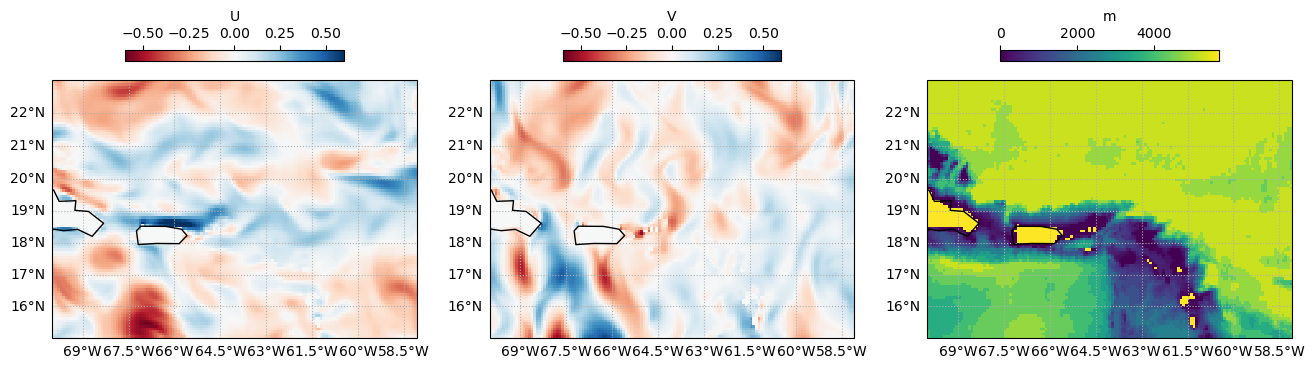

In [66]:
fig=plt.figure(figsize=(16,5))
pr1=ccrs.PlateCarree()
pr2=ccrs.Mercator()
ax1 = fig.add_subplot(1, 3, 1, projection=pr2)
a=ax1.pcolormesh(fieldset.U.grid.lon,fieldset.U.grid.lat,fieldset.U.data[0,0,:-1,:-1],shading='flat',transform=pr1,vmin=-0.6,vmax=0.6,cmap=plt.get_cmap('RdBu'))
ax1.coastlines(resolution='110m',zorder=10)
plt.colorbar(a,location='top',shrink=0.6,label='U')
ga=ax1.gridlines(linestyle=':',draw_labels=True)
ga.top_labels, ga.right_labels = False, False
ax1 = fig.add_subplot(1, 3, 2, projection=pr2)
a=ax1.pcolormesh(fieldset.V.grid.lon,fieldset.V.grid.lat,fieldset.V.data[0,0,:-1,:-1],shading='flat',transform=pr1,vmin=-0.6,vmax=0.6,cmap=plt.get_cmap('RdBu'))
ax1.coastlines(resolution='110m',zorder=10)
plt.colorbar(a,location='top',shrink=0.6,label='V')
ga=ax1.gridlines(linestyle=':',draw_labels=True)
ga.top_labels, ga.right_labels = False, False
ax1 = fig.add_subplot(1, 3, 3, projection=pr2)
a=ax1.pcolormesh(fieldset.bathy.grid.lon,fieldset.bathy.grid.lat,fieldset.bathy.data[0,:-1,:-1],shading='flat',transform=pr1,cmap=plt.get_cmap('viridis'),vmin=0)
ax1.coastlines(resolution='110m',zorder=10)
ga=ax1.gridlines(linestyle=':',draw_labels=True)
ga.top_labels, ga.right_labels = False, False
plt.colorbar(a,location='top',shrink=0.6,label='m')

In [74]:
mission = FloatConfiguration('default')
mission.update('parking_depth', 1000)
mission.update('profile_depth', 1000)
mission.update('cycle_duration', 1*24)
mission

<FloatConfiguration><default>
- cycle_duration (Maximum length of float complete cycle): 24.0 [hours]
- life_expectancy (Maximum number of completed cycle): 200 [cycle]
- parking_depth (Drifting depth): 1000.0 [m]
- profile_depth (Maximum profile depth): 1000.0 [m]
- vertical_speed (Vertical profiling speed): 0.09 [m/s]

In [75]:
lon0, lat0 = -62.5, 19.4
Lx, Ly = 1., 1. # Size of the box
fbox = [lon0-Lx/2,lat0-Ly/2,lon0+Lx/2,lat0+Ly/2]
coords=np.array(list(itertools.product(np.linspace(fbox[0],fbox[2],10),np.linspace(fbox[1],fbox[3],10))))
lon = coords[:,0]
lat = coords[:,1]
nfloats=len(lon)
dpt = np.linspace(min_depth, min_depth, nfloats) #1m depth
tim = np.array(['2021-11-01' for i in range(nfloats)],dtype='datetime64')
my_plan = {'lat': lat, 
           'lon': lon, 
           'time': tim, 
           'depth':dpt}

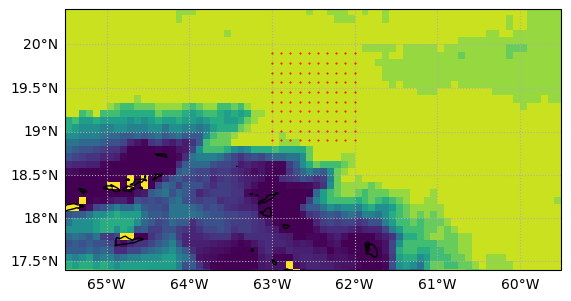

In [76]:
fig=plt.figure()
pr1=ccrs.PlateCarree()
pr2=ccrs.Mercator()
ax1 = fig.add_subplot(1, 1, 1, projection=pr2)
a=ax1.pcolormesh(fieldset.U.grid.lon,fieldset.U.grid.lat,fieldset.bathy.data[0,:-1,:-1],shading='flat',transform=pr1,cmap=plt.get_cmap('viridis'),vmin=0)
#b=ax1.contourf(fieldset.bathy.grid.lon,fieldset.bathy.grid.lat,fieldset.bathy.data[0,:,:],np.arange(990,1010),transform=pr1)
ax1.coastlines(resolution='10m',zorder=10)
ga=ax1.gridlines(linestyle=':',draw_labels=True)
ga.top_labels, ga.right_labels = False, False
ax1.plot(my_plan['lon'],my_plan['lat'],'r.',markersize=1,transform=pr1)
ax1.set_extent([lon0-3,lon0+3,lat0-2,lat0+1])

In [77]:
VFleet = VirtualFleet(plan=my_plan, fieldset=VELfield, mission=mission, verbose_events=False)
VFleet

<VirtualFleet>
- 100 floats in the deployment plan
- No simulation performed

In [78]:
VFleet.simulate(
    duration=timedelta(days=30),
    step=timedelta(minutes=5),
    record=timedelta(minutes=60),
    output_file="coastal_float.zarr",
    output_folder="data/"
)

/home/kbalem/Bureau/VirtualFleet/virtualargofleet/virtualargofleet.py:361: UserWarning: Simulation will be saved in : data/coastal_float.zarr
  warnings.warn(output_msg)


INFO: Output files are stored in data/coastal_float.zarr.
  0%|▏                                                    | 7500.0/2592000.0 [00:00<01:10, 36628.76it/s]

/home/kbalem/miniforge3/envs/x26K/lib/python3.11/site-packages/parcels/particledata.py:358: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  np.less_equal(time - np.abs(pd["dt"] / 2), pd["time"], where=np.isfinite(pd["time"]))
/home/kbalem/miniforge3/envs/x26K/lib/python3.11/site-packages/parcels/particledata.py:359: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  & np.greater_equal(time + np.abs(pd["dt"] / 2), pd["time"], where=np.isfinite(pd["time"]))
/home/kbalem/miniforge3/envs/x26K/lib/python3.11/site-packages/parcels/particledata.py:360: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  | ((np.isnan(pd["dt"])) & np.equal(time, pd["time"], where=np.isfinite(pd["time"])))


  4%|█▉                                                  | 93600.0/2592000.0 [00:01<00:43, 56831.36it/s]

/home/kbalem/miniforge3/envs/x26K/lib/python3.11/site-packages/parcels/particledata.py:358: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  np.less_equal(time - np.abs(pd["dt"] / 2), pd["time"], where=np.isfinite(pd["time"]))
/home/kbalem/miniforge3/envs/x26K/lib/python3.11/site-packages/parcels/particledata.py:359: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  & np.greater_equal(time + np.abs(pd["dt"] / 2), pd["time"], where=np.isfinite(pd["time"]))
/home/kbalem/miniforge3/envs/x26K/lib/python3.11/site-packages/parcels/particledata.py:360: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  | ((np.isnan(pd["dt"])) & np.equal(time, pd["time"], where=np.isfinite(pd["time"])))


...

/home/kbalem/miniforge3/envs/x26K/lib/python3.11/site-packages/parcels/particledata.py:358: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  np.less_equal(time - np.abs(pd["dt"] / 2), pd["time"], where=np.isfinite(pd["time"]))
/home/kbalem/miniforge3/envs/x26K/lib/python3.11/site-packages/parcels/particledata.py:359: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  & np.greater_equal(time + np.abs(pd["dt"] / 2), pd["time"], where=np.isfinite(pd["time"]))
/home/kbalem/miniforge3/envs/x26K/lib/python3.11/site-packages/parcels/particledata.py:360: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  | ((np.isnan(pd["dt"])) & np.equal(time, pd["time"], where=np.isfinite(pd["time"])))


 93%|██████████████████████████████████████████████▋   | 2422800.0/2592000.0 [00:49<00:03, 42828.73it/s]

/home/kbalem/miniforge3/envs/x26K/lib/python3.11/site-packages/parcels/particledata.py:358: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  np.less_equal(time - np.abs(pd["dt"] / 2), pd["time"], where=np.isfinite(pd["time"]))
/home/kbalem/miniforge3/envs/x26K/lib/python3.11/site-packages/parcels/particledata.py:359: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  & np.greater_equal(time + np.abs(pd["dt"] / 2), pd["time"], where=np.isfinite(pd["time"]))
/home/kbalem/miniforge3/envs/x26K/lib/python3.11/site-packages/parcels/particledata.py:360: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  | ((np.isnan(pd["dt"])) & np.equal(time, pd["time"], where=np.isfinite(pd["time"])))


100%|██████████████████████████████████████████████████| 2592000.0/2592000.0 [00:53<00:00, 48747.85it/s]


<VirtualFleet>
- 100 floats in the deployment plan
- Number of simulation(s): 1
- Last simulation meta-data:
	- Duration: 30d 00h 00m 00s
	- Data recording every: 01h 00m
	- Trajectory file: data/coastal_float.zarr
	- Execution time: 00d 00h 00m 57s
	- Executed on: L-BR-LOPS-P26

In [72]:
VFleet

<VirtualFleet>
- 100 floats in the deployment plan
- Number of simulation(s): 1
- Last simulation meta-data:
	- Duration: 30d 00h 00m 00s
	- Data recording every: 01h 00m
	- Trajectory file: data/surface_drifter.zarr
	- Execution time: 00d 00h 00m 55s
	- Executed on: L-BR-LOPS-P26

In [79]:
dz = xr.open_dataset('data/coastal_float.zarr') # simulation of a coastal float

In [80]:
dz2 = xr.open_dataset('data/surface_drifter.zarr') # simulation of a surface float

In [22]:
etopo = xr.open_dataset('/home/kbalem/Bureau/ETOPO1_Bed_g_gmt4.nc')

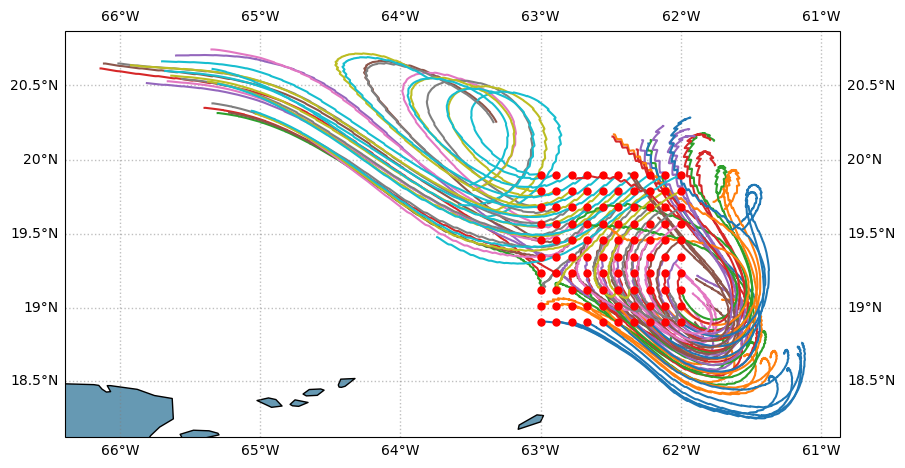

In [81]:
pr1=ccrs.PlateCarree()
pr2=ccrs.Mercator()

fig=plt.figure(figsize=(10,10))
ax3 = fig.add_subplot(1,1,1,projection=pr2)
ax3.add_feature(land_feature, edgecolor='black')
ax3.gridlines(linewidth=1, color='gray', alpha=0.5, linestyle=':',draw_labels=True)

for i in dz.trajectory.values:
    tmp=dz.sel(trajectory=i).sortby('time')
    ax3.plot(tmp['lon'][0],tmp['lat'][0],'ro',markersize=5,transform=pr1,zorder=10)
    ax3.plot(tmp['lon'],tmp['lat'],linewidth=1.5,transform=pr1)

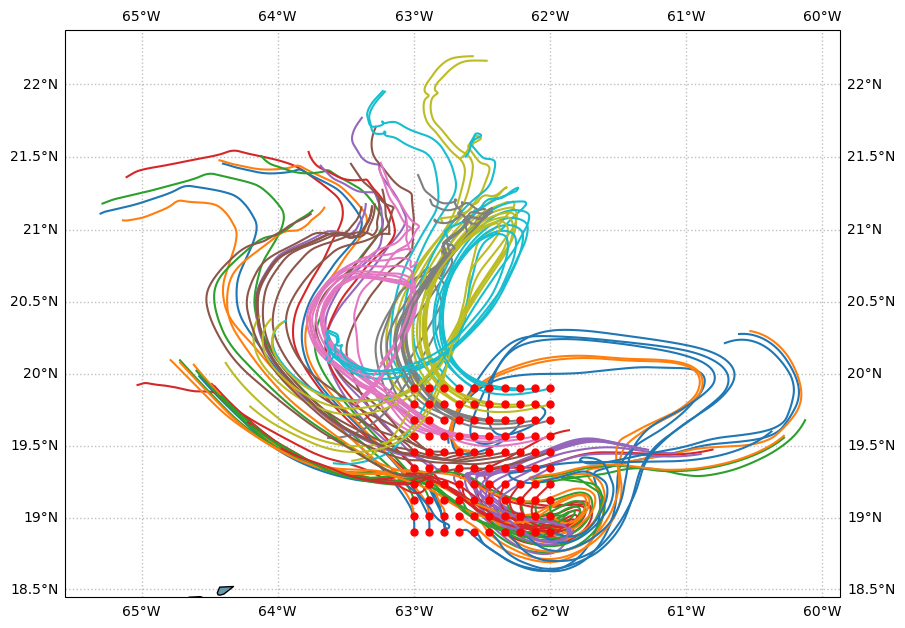

In [82]:
pr1=ccrs.PlateCarree()
pr2=ccrs.Mercator()

fig=plt.figure(figsize=(10,10))
ax3 = fig.add_subplot(1,1,1,projection=pr2)
ax3.add_feature(land_feature, edgecolor='black')
ax3.gridlines(linewidth=1, color='gray', alpha=0.5, linestyle=':',draw_labels=True)

for i in dz2.trajectory.values:
    tmp=dz2.sel(trajectory=i).sortby('time')
    ax3.plot(tmp['lon'][0],tmp['lat'][0],'ro',markersize=5,transform=pr1,zorder=10)
    ax3.plot(tmp['lon'],tmp['lat'],linewidth=1.5,transform=pr1)

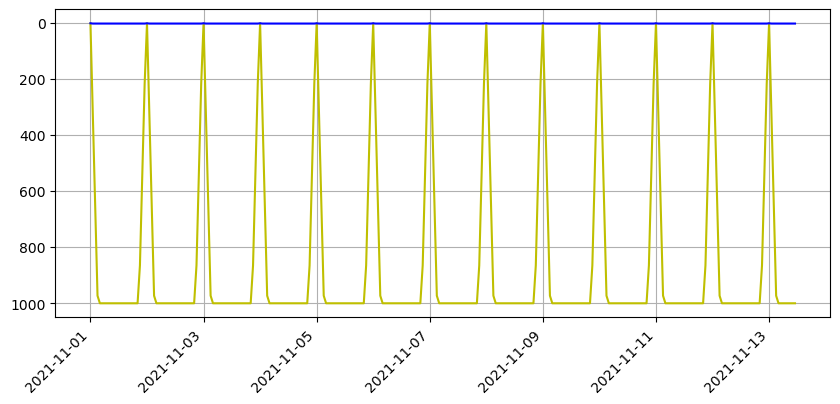

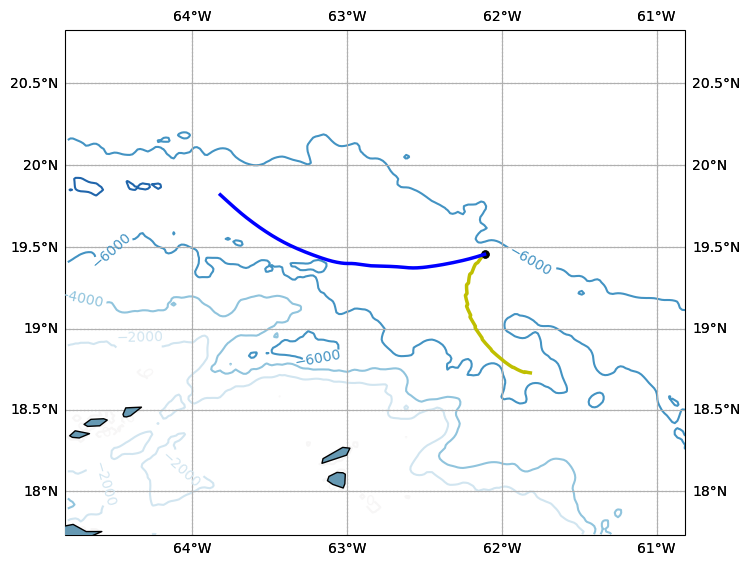

In [87]:
tr=85
tmp=dz.isel(trajectory=tr,obs=slice(0,300)).sortby('time')
tmp2=dz2.isel(trajectory=tr,obs=slice(0,300)).sortby('time')

f,ax = plt.subplots(figsize=(10,4))
ax.plot(tmp.time,tmp.z,'y-')
ax.plot(tmp2.time,tmp2.z,'b-')
ax.invert_yaxis()
ax.grid(':')
_=plt.xticks(rotation=45, ha='right')

fig=plt.figure(figsize=(8,8))
ax3 = fig.add_subplot(1,1,1,projection=pr2)


ax3.gridlines(linewidth=1, color='gray', alpha=0.5, linestyle=':',draw_labels=True)

extent = [np.min([tmp.lon.min(),tmp2.lon.min()])-1,
          np.max([tmp.lon.max(),tmp2.lon.max()])+1,
          np.min([tmp.lat.min(),tmp2.lat.min()])-1,
          np.max([tmp.lat.max(),tmp2.lat.max()])+1]
ax3.set_extent(extent)

cs=etopo.sel(y=slice(extent[2], extent[3]), x=slice(extent[0], extent[1]),drop=True)['z'].plot.contour(levels=10,transform=pr1)
ax3.clabel(cs, inline=True, fontsize=10,)
ax3.gridlines(draw_labels=True)
ax3.plot(tmp['lon'][0],tmp['lat'][0],'k.',markersize=10,transform=pr1)
ax3.plot(tmp['lon'],tmp['lat'],'y',linewidth=2.5,transform=pr1)

ax3.plot(tmp2['lon'][0],tmp2['lat'][0],'k.',markersize=10,transform=pr1)
ax3.plot(tmp2['lon'],tmp2['lat'],'b',linewidth=2.5,transform=pr1)

ax3.add_feature(land_feature, edgecolor='black',zorder=10)